# 01 — Exploratory Data Analysis (C-MAPSS FD001)

**Independent R&D prototype on public NASA data — not Caterpillar data, not production.** See `docs/data-sources.md` for the citation and the proxy caveat.

This notebook is intentionally thin: all logic lives in `src/`, the notebook just tells the story.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /home/lu2/dev/personal/projects/learning/genai-condition-monitoring-prototype


In [2]:
from src.data.load_cmapss import load_raw, add_training_rul, RUL_CAP
from src.features.build_features import (
    INFORMATIVE_SENSORS, DROPPED_SENSORS)
train = load_raw('FD001', 'train')
print('shape:', train.shape, '| units:', train.unit.nunique())
train.head()

shape: (20631, 26) | units: 100


## Target: Remaining Useful Life (RUL)

Training RUL = (last cycle of the unit) − (current cycle), capped at **125** cycles. The cap encodes 'anything beyond ~125 cycles of remaining life is simply healthy', which stabilises the regression target — see the loader docstring.

count    20631.0
mean        86.8
std         41.7
min          0.0
25%         51.0
50%        103.0
75%        125.0
max        125.0


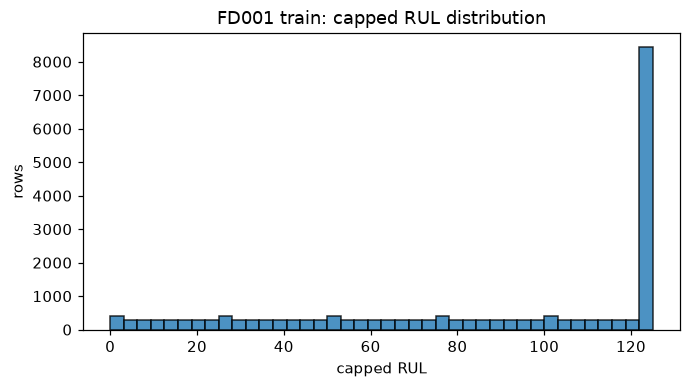

In [3]:
train_rul = add_training_rul(train)
print(train_rul['rul'].describe().round(1).to_string())
fig, ax = plt.subplots(figsize=(7,3.5))
ax.hist(train_rul['rul'], bins=40, edgecolor='k', alpha=0.8)
ax.set_xlabel('capped RUL'); ax.set_ylabel('rows')
ax.set_title('FD001 train: capped RUL distribution')
None

## Which sensors carry signal?

FD001 is a single operating condition + single fault mode, so several sensors are constant or near-constant and are dropped. The rest trend monotonically as the engine degrades.

In [4]:
sensor_cols = [c for c in train.columns if c.startswith('sensor_')]
stds = train[sensor_cols].std().sort_values()
print('Dropped (constant/near-constant):', DROPPED_SENSORS)
print('Informative (%d):' % len(INFORMATIVE_SENSORS), INFORMATIVE_SENSORS)
stds.round(4).to_frame('std')

Dropped (constant/near-constant): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Informative (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


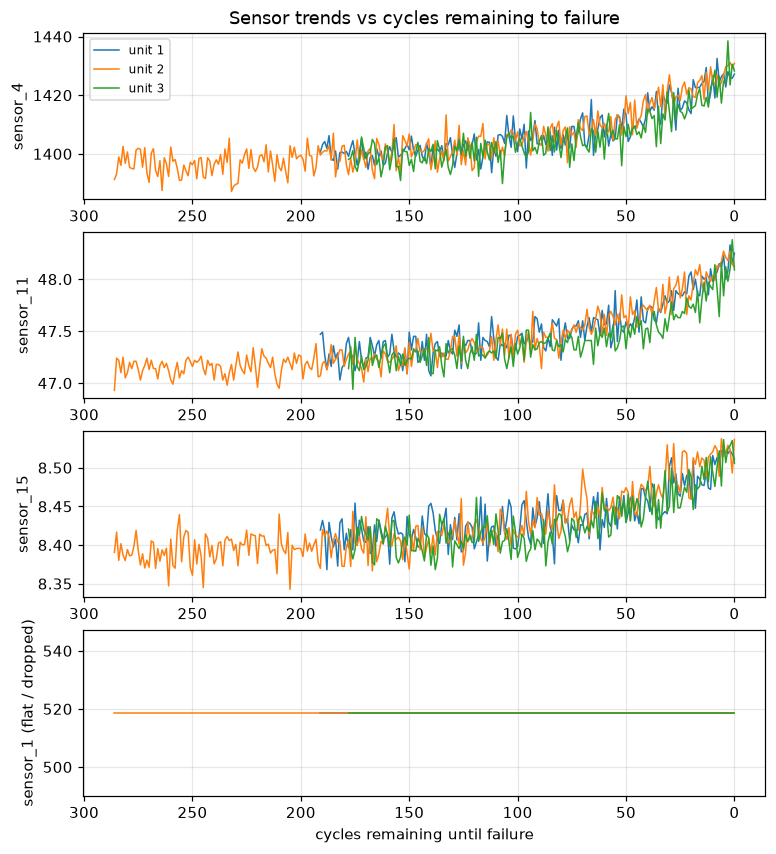

In [5]:
# Degradation: informative sensors vs cycles-to-failure for 3 units;
# plus one flat (dropped) sensor for contrast.
units = [1, 2, 3]
panels = ['sensor_4', 'sensor_11', 'sensor_15', 'sensor_1']
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 9))
for ax, s in zip(axes, panels):
    for u in units:
        g = train[train.unit == u]
        ax.plot(g.cycle.max() - g.cycle, g[s], linewidth=1, label=f'unit {u}')
    ax.set_ylabel(s); ax.invert_xaxis(); ax.grid(alpha=0.3)
flat = ' (flat / dropped)'
axes[-1].set_ylabel(panels[-1] + flat)
axes[0].set_title('Sensor trends vs cycles remaining to failure')
axes[-1].set_xlabel('cycles remaining until failure')
axes[0].legend(fontsize=8)
None

**Takeaways.** Informative sensors (4, 11, 15, …) drift steadily as failure approaches — that drift is the learnable signal. Sensor 1 is flat and is dropped. The rolling mean/std features in `src/features/build_features.py` denoise and quantify this drift.